<a href="https://colab.research.google.com/github/Arjun-kumar22/DEEP_Learning/blob/main/Text_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df =  pd.read_csv('/content/IMDB Dataset.csv')

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


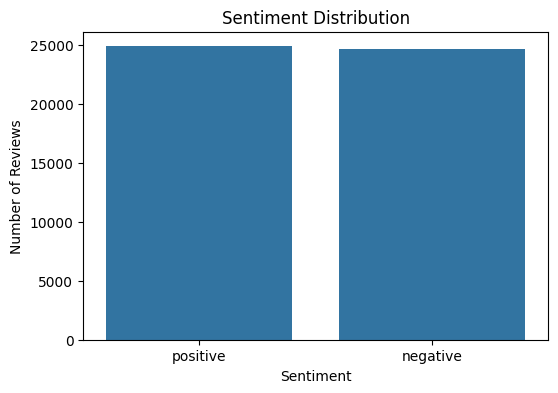

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)

In [ ]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [ ]:
X = df["clean_review"]
y = df["sentiment"]

In [ ]:
print(X.head())
print(y.head())

0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically there s a family where a little boy ...
4    petter mattei s love in the time of money is a...
Name: clean_review, dtype: object
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


In [ ]:
y = y.map({
    "negative": 0,
    "positive": 1
})

In [ ]:
y.value_counts()

,count
sentiment,
1,24884
0,24698


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [ ]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
tfidf.fit_transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 915490 stored elements and shape (9917, 20000)>

In [ ]:
print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Training TF-IDF shape: (39665, 20000)
Testing TF-IDF shape: (9917, 20000)


**Model 1: Logistic Regression**

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [ ]:
lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr_model.predict(
    X_test_tfidf
)

Evaluate Logistic Regression

In [ ]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

precision_lr = precision_score(
    y_test,
    y_pred_lr
)

recall_lr = recall_score(
    y_test,
    y_pred_lr
)

f1_lr = f1_score(
    y_test,
    y_pred_lr
)

In [ ]:
print("Logistic Regression")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-score :", f1_lr)

Logistic Regression
Accuracy : 0.8965412927296561
Precision: 0.8860660543287082
Recall   : 0.9109905565601768
F1-score : 0.8983554586883297


**Model 2: Naive Bayes**

In [ ]:
nb_model = MultinomialNB()

In [ ]:
nb_model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(
    X_test_tfidf
)

**Evaluate:**

In [ ]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

precision_nb = precision_score(
    y_test,
    y_pred_nb
)

recall_nb = recall_score(
    y_test,
    y_pred_nb
)

f1_nb = f1_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1-score :", f1_nb)

Naive Bayes
Accuracy : 0.8709287082787133
Precision: 0.8638063373351702
Recall   : 0.8818565400843882
F1-score : 0.8727381189103202


**Model 3: Linear SVM**

In [ ]:
svm_model = LinearSVC()

In [ ]:
svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC()

In [ ]:
y_pred_svm = svm_model.predict(
    X_test_tfidf
)


In [ ]:
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_svm
)

recall_svm = recall_score(
    y_test,
    y_pred_svm
)

f1_svm = f1_score(
    y_test,
    y_pred_svm
)

print("Linear SVM")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1-score :", f1_svm)

Linear SVM
Accuracy : 0.8919027931834224
Precision: 0.8879395986489171
Recall   : 0.8979304802089613
F1-score : 0.8929070929070929


**Classification Reports**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [ ]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      4940
    Positive       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



In [ ]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      4940
    Positive       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



LOGISTIC REGRESSION

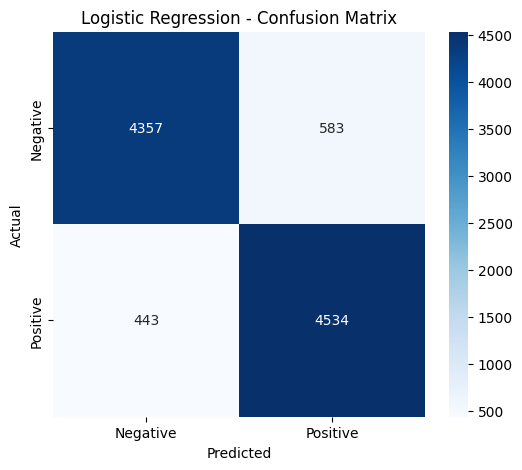

In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

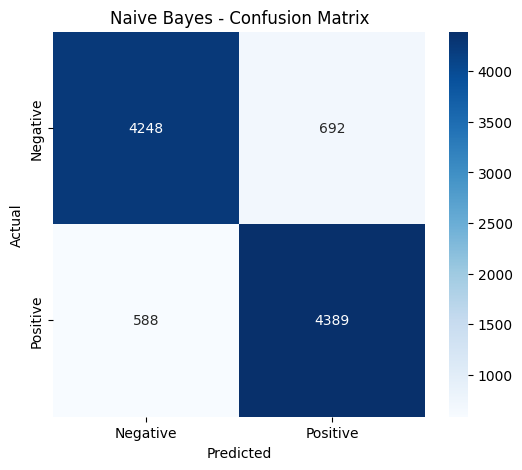

In [ ]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")

plt.show()

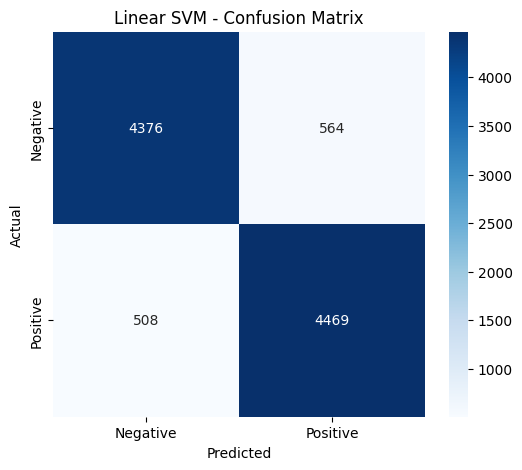

In [ ]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - Confusion Matrix")

plt.show()

Final comparison table

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_nb,
        accuracy_svm
    ],

    "Precision": [
        precision_lr,
        precision_nb,
        precision_svm
    ],

    "Recall": [
        recall_lr,
        recall_nb,
        recall_svm
    ],

    "F1-Score": [
        f1_lr,
        f1_nb,
        f1_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.896541,0.886066,0.910991,0.898355
1,Naive Bayes,0.870929,0.863806,0.881857,0.872738
2,Linear SVM,0.891903,0.887940,0.897930,0.892907


In [ ]:
results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.896541,0.886066,0.910991,0.898355
2,Linear SVM,0.891903,0.887940,0.897930,0.892907
1,Naive Bayes,0.870929,0.863806,0.881857,0.872738


In [ ]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.896541
Precision               0.886066
Recall                  0.910991
F1-Score                0.898355
Name: 0, dtype: object


**Conclusion

The Logistic Regression model performed best for sentiment classification, achieving 89.65% accuracy and an F1-score of 89.84%. Its high precision (88.61%) and recall (91.10%) indicate that it can effectively distinguish between positive and negative reviews. Therefore, Logistic Regression was identified as the best-performing model among the evaluated models.**